# Random Upper-Level Parameter Search for Building Thermal Control

In [43]:
# Resolve configurable_mdp root for common working directories
import sys
from pathlib import Path

cwd = Path.cwd().resolve()
if (cwd / "src").exists():
    module_root = cwd
elif (cwd / "configurable_mdp" / "src").exists():
    module_root = cwd / "configurable_mdp"
elif cwd.name == "notebooks" and (cwd.parent / "src").exists():
    module_root = cwd.parent
else:
    raise RuntimeError(f"Could not locate configurable_mdp root from cwd={cwd}")

module_path = str(module_root)
if module_path not in sys.path:
    sys.path.insert(0, module_path)

print(f"module_path = {module_path}")
print(f"src import ready: {(Path(module_path) / 'src').exists()}")

module_path = /home/mikoto/workspace/BC-HG/configurable_mdp
src import ready: True


In [44]:
# module install
import os
import jax
import jax.numpy as jnp
import functools
import time
import yaml
import pickle
from typing import Dict
from typing import Callable, Optional
from optax import TraceState
import matplotlib.pyplot as plt

from src.algorithms.regularized_lqr import (
    create_regularized_lqr,
    Transition,
    RegularizedLQROutputs,
    RegularizedLQRPolicy,
    update_dictionary,
)
from train_bilevel_lqr_hpgd import (
    setup_environment,
)
from src.models.StaticModel import create_state_model as create_static_train_state
from src.environments.BuildingThermalControl import (
    BuildingThermalControl,
    EnvParams,
    EnvState,
)
from src.train.utils import check_if_jittable

colors = plt.cm.Dark2.colors  # 8 distinct colors
linewidth = 2.5
figsize = (8.0, 4.8)  # slightly smaller plot box to keep text readable after placement
base_font_size = 20
legend_font_size = 18  # keep legend relatively smaller than other text
axis_label_font_size = 22  # make axis labels slightly larger
plt.rcParams.update(
    {
        'font.size': base_font_size,
        'axes.labelsize': axis_label_font_size,
        'legend.fontsize': legend_font_size,
        'text.usetex': True,
        'axes.linewidth': linewidth,
        'xtick.major.width': linewidth,
        'ytick.major.width': linewidth,
        'xtick.major.size': 2*linewidth,
        'ytick.major.size': 2*linewidth,
        'axes.prop_cycle': plt.cycler(color=colors),
        'lines.linewidth': linewidth,
    }
)

In [45]:
# CONFIGURATION
seed = 42
num_samples = 10000
save = True
data_dir = "../data/experiment_bilevel_lqr_reg_lambda_0_1_steps_10000"
# save_dir = os.path.join(data_dir, "figures", "random_search")
save_dir = os.getcwd()

In [46]:
def create_trajectory_batch_sample(
    config_create: Dict,
    env: BuildingThermalControl,
    for_eval: bool,
) -> Callable[[jax.random.PRNGKey, TraceState, EnvParams, Optional[float]], Transition]:
    """
    Create the trajectory batch sampling function
    :param config_create:
    :param env:
    :param env_params:
    :return:
    """
    vmap_reset = lambda n_envs: lambda rng, params: jax.vmap(
        env.reset, in_axes=(0, None)
    )(jax.random.split(rng, n_envs), params)
    vmap_step = lambda n_envs: lambda rng, env_state, action, params: jax.vmap(
        env.step, in_axes=(0, 0, 0, None)
    )(jax.random.split(rng, n_envs), env_state, action, params)

    @jax.jit
    def get_trajectory_batch(
        key: jax.random.PRNGKey,
        lqr_output: RegularizedLQROutputs,
        env_params_sampling: EnvParams,
    ):
        policy = RegularizedLQRPolicy(
            Ks=lqr_output.Ks,
            Sigma=lqr_output.Sigma,
            sqrtSigma=lqr_output.sqrtSigma
        )

        def rollout_step(carry, unused):
            rng_carry, env_state_carry, last_obs = carry
            rng_carry, rng_a1, rng_s = jax.random.split(rng_carry, 3)            
            
            # Get the action
            rng_keys = jax.random.split(rng_a1, config_create["num_envs"])
            action = policy.get_actions(last_obs, rng_keys)

            obs, env_state_carry_new, reward, done, info = vmap_step(
                config_create["num_envs"]
            )(rng_s, env_state_carry, action, env_params_sampling)
            transition = Transition(
                obs=last_obs,
                action=action,
                reward=reward,
                done=done,
                state=env_state_carry,
            )

            carry = (rng_carry, env_state_carry_new, obs)
            return carry, transition

        key_init, key_rollout = jax.random.split(key, 2)
        init_obs, init_env_state = vmap_reset(config_create["num_envs"])(
            key_init, env_params_sampling
        )
        steps = (config_create["num_estimation_steps"] if not for_eval
                 else config_create["num_eval_steps"])
        _, traj_batch = jax.lax.scan(
            rollout_step,
            (key_rollout, init_env_state, init_obs),
            None,
            steps // config_create["num_envs"],
        )
        return traj_batch

    return get_trajectory_batch

# Uniformly Sample Upper-Level Parameter (insulation_level)
def create_parameter_sampling_fn(scale_range, n_dim, num_samples):

    @jax.jit
    def sample_parameters_batch(key):
        keys = jax.random.split(key, num_samples)
        min_val, max_val = scale_range
        
        def sample_single(single_key):
            return jax.random.uniform(
                single_key, 
                shape=(n_dim,), 
                dtype=jnp.float32, 
                minval=min_val, 
                maxval=max_val
            )
        
        return jax.vmap(sample_single)(keys)  # Shape: (num_samples, n_dim)
    return sample_parameters_batch

In [47]:
def run(env, env_params: EnvParams, seed: int, num_samples: int, config: dict):    

    regularized_lqr = create_regularized_lqr(env, config['lower_optimisation'])
    state_dim = env_params.transition_params.A.shape[0]
    action_dim = env_params.transition_params.B.shape[1]

    initial_state = RegularizedLQROutputs(
        A=env_params.transition_params.A, 
        B=env_params.transition_params.B, 
        Q=env_params.reward_params.Q, 
        R=env_params.reward_params.R, 
        W=env.compute_process_noise_covariance(env_params.transition_params),
        P=env_params.reward_params.Q.copy(),  # Fixed initial P
        v=jnp.array(0.0),                     # Fixed initial v
        Ks=jnp.zeros((action_dim, state_dim)),
        Sigma=jnp.eye(action_dim),
        sqrtSigma=jnp.eye(action_dim)
    )

    # Execute Lower-Level LQR for Each Sampled Parameter
    def run_single_experiment(
        insulation_param: jnp.ndarray,
        airflow_param: jnp.ndarray,
        env_params_base: EnvParams,
    ):
        updated_env_params = env_params_base.replace(
            transition_params=env_params_base.transition_params.replace(
                insulation_level=insulation_param,
                airflow_adjustment=airflow_param
            )
        )
        
        # Run LQR
        outputs, metrics, valid_metrics = regularized_lqr(
            env_params_train=updated_env_params,
            train_states_carry=initial_state,
        )
        
        return {
            "insulation_level": insulation_param,
            "airflow_adjustment": airflow_param,
            "metrics": metrics,
            "lqr_state": outputs  # RegularizedLQROutputs
        }
        
    # Main Execution Flow
    key = jax.random.PRNGKey(seed)
    key, _rng1, _rng2 = jax.random.split(key, 3)

    n_dim_insulation_level = env_params.transition_params.num_zones
    n_dim_airflow_adjustment = env_params.transition_params.num_zones
    scale_range = (
        config["upper_optimisation"]["model_params"]["scale"][0], 
        config["upper_optimisation"]["model_params"]["scale"][1]
    )

    # Sample Upper-Level Parameters
    sample_parameters_batch_IL = create_parameter_sampling_fn(
        scale_range, n_dim_insulation_level, num_samples
    )
    insulation_params = sample_parameters_batch_IL(
        _rng1
    )  # Shape: (num_samples, n_dim_insulation_level)
    sample_parameters_batch_AA = create_parameter_sampling_fn(
        scale_range, n_dim_airflow_adjustment, num_samples
    )
    airflow_params = sample_parameters_batch_AA(
        _rng2
    )  # Shape: (num_samples, n_dim_airflow_adjustment)

    experiment_keys = jax.random.split(key, num_samples)  # Shape: (num_samples, 2)

    lqr_results = jax.vmap(
        run_single_experiment, 
        in_axes=(0, 0, None)
    )(
        insulation_params, 
        airflow_params,
        env_params
    )

    get_trajectory_batch = create_trajectory_batch_sample(
        config["upper_optimisation"],
        env,
        for_eval=True,
    )

    def add_trajectories_to_result(i):
        key_i = experiment_keys[i]
        lqr_result = jax.tree_map(lambda x: x[i], lqr_results)
        
        updated_env_params = env_params.replace(
            transition_params=env_params.transition_params.replace(
                insulation_level=insulation_params[i],
                airflow_adjustment=airflow_params[i]
            )
        )
        
        trajectories = get_trajectory_batch(
            key_i, lqr_result["lqr_state"], updated_env_params
        )
        
        return {
            "trajectories": trajectories,
            "insulation_level": lqr_result["insulation_level"],
            "airflow_adjustment": lqr_result["airflow_adjustment"],
            "metrics": lqr_result["metrics"],
        }
    
    outputs = [add_trajectories_to_result(i) for i in range(num_samples)]
    
    # Convert results to the appropriate format
    final_outputs = jax.tree_map(
        lambda *args: jnp.stack(args, axis=0), 
        *outputs
    )
    
    return final_outputs

## Run or Load

In [48]:
output_path = os.path.join(data_dir, f"random_search_results_n{num_samples}seed{seed}.pkl")

with open(f"{data_dir}/config.yaml", "r") as f:
    config = yaml.safe_load(f)  # Assume no grid search for required parameters
env, env_params = setup_environment(config['environment'])

if os.path.exists(output_path):
    print(f"Loading existing results from {output_path}")
    with open(output_path, "rb") as f:
        outputs = pickle.load(f)
else:
    print("Running random search experiments...")
    start = time.time()
    outputs = run(env, env_params, seed, num_samples, config)
    end = time.time()
    print(f"Total time taken: {end - start} seconds")

    # Save outputs
    if save:
        with open(output_path, "wb") as f:
            pickle.dump(outputs, f)
        print(f"Output saved to {output_path}")

Running random search experiments...
Total time taken: 264.0629143714905 seconds
Output saved to ../data/experiment_bilevel_lqr_reg_lambda_0_1_steps_10000/random_search_results_n10000seed42.pkl


# Make histograms and parameter scatter plots

In [49]:
UL_reward_param_override = {
    "stability_weight":       1.0,
    "energy_weight":          0.5,
    "insulation_cost_weight": 0.1,
    "airflow_cost_weight":    0.1,
}
if UL_reward_param_override is not None:
    env_params = env_params.replace(
        reward_params=env_params.reward_params.replace(
            stability_weight=UL_reward_param_override["stability_weight"],
            energy_weight=UL_reward_param_override["energy_weight"],
            insulation_cost_weight=UL_reward_param_override["insulation_cost_weight"],
            airflow_cost_weight=UL_reward_param_override["airflow_cost_weight"],
        )
    )
    reward_params_label = f"_SR_{env_params.reward_params.stability_weight}_" \
        f"EC_{env_params.reward_params.energy_weight}_" \
        f"IC_{env_params.reward_params.insulation_cost_weight}_" \
        f"AC_{env_params.reward_params.airflow_cost_weight}"
    reward_params_label = reward_params_label.replace(".", "_")
else:
    reward_params_label = ""
reward_params_str = r"$\kappa_{\mathrm{SR}}$=" + f"{env_params.reward_params.stability_weight} " \
    r"$\kappa_{\mathrm{EC}}$=" + f"{env_params.reward_params.energy_weight} " \
    r"$\kappa_{\mathrm{IC}}$=" + f"{env_params.reward_params.insulation_cost_weight} " \
    r"$\kappa_{\mathrm{AC}}$=" + f"{env_params.reward_params.airflow_cost_weight}"

In [50]:
# Prepare Data for Analysis
traj_batch = outputs['trajectories']
"""
traj_batch.obs  # Shape: (num_samples, num_steps, num_envs, obs_dim)
traj_batch.action  # Shape: (num_samples, num_steps, num_envs, action_dim)
traj_batch.reward  # Shape: (num_samples, num_steps, num_envs)
traj_batch.done  # Shape: (num_samples, num_steps, num_envs)
traj_batch.state  # Shape: (num_samples, num_steps, num_envs, ...)
"""

# Set Upper-level Parameters
insulation_level = outputs['insulation_level']  # Shape: (num_samples, n_dim_insulation_level)
airflow_adjustment = outputs['airflow_adjustment']  # Shape: (num_samples, n_dim_airflow_adjustment)

# Compute Upper-Level Immediate Rewards for Each Trajectory
reward_UL, info = jax.vmap(
    lambda s, a, pi, pa: jax.vmap(
        jax.vmap(
            env.upper_level_reward, 
            in_axes=(0, 0, None)
        ), 
        in_axes=(0, 0, None)
    )(
        s,  # Shape: (num_steps, num_envs, ...)
        a,  # Shape: (num_steps, num_envs, action_dim)
        env_params.replace(
            transition_params=env_params.transition_params.replace(
                insulation_level=pi,
                airflow_adjustment=pa
            )
        )
    ),
    in_axes=(0, 0, 0, 0)
    )(
    traj_batch.state,   # Shape: (num_samples, num_steps, num_envs, ...)
    traj_batch.action,  # Shape: (num_samples, num_steps, num_envs, action_dim)
    insulation_level,   # Shape: (num_samples, n_dim_insulation_level)
    airflow_adjustment  # Shape: (num_samples, n_dim_airflow_adjustment)
)

# Compute Cumulative Upper-Level Returns
discounting_arr = jnp.power(
    config["lower_optimisation"]["discount_factor"],
    traj_batch.state.time,
)  # Shape: (num_samples, num_steps, num_envs)
num_episodes = jnp.sum(traj_batch.done, axis=(1, 2))  # Shape: (num_samples,)

return_UL_stability = jnp.sum(
    info["stability_reward"] * discounting_arr, axis=(1, 2)
) / jnp.clip(num_episodes, a_min=1)  # Shape: (num_samples,)
return_UL_energy_cost = jnp.sum(
    info["energy_cost"] * discounting_arr, axis=(1, 2)
) / jnp.clip(num_episodes, a_min=1)  # Shape: (num_samples,)
return_UL_insulation_cost = jnp.sum(
    info["insulation_cost"] * discounting_arr, axis=(1, 2)
) / jnp.clip(num_episodes, a_min=1)  # Shape: (num_samples,)
return_UL_airflow_cost = jnp.sum(
    info["airflow_cost"] * discounting_arr, axis=(1, 2)
) / jnp.clip(num_episodes, a_min=1)  # Shape: (num_samples,)

return_UL = (
    env_params.reward_params.stability_weight * return_UL_stability
    - env_params.reward_params.energy_weight * return_UL_energy_cost
    - env_params.reward_params.insulation_cost_weight * return_UL_insulation_cost
    - env_params.reward_params.airflow_cost_weight * return_UL_airflow_cost
)  # Shape: (num_samples,)

return_LL = jnp.sum(
    traj_batch.reward * discounting_arr, axis=(1, 2)
) / jnp.clip(num_episodes, a_min=1)  # Shape: (num_samples,)

# Analyze System Stability via Eigenvalues of A Matrix
A = jax.vmap(
    lambda il, aa: env.compute_parameterized_A(
        env_params.transition_params.replace(
            insulation_level=il,
            airflow_adjustment=aa
        )
    ),
    in_axes=(0, 0)
)(insulation_level, airflow_adjustment)

with jax.default_device(jax.devices('cpu')[0]):
    eig_values_stable = jax.vmap(
        lambda A: jnp.linalg.eigvals(A), in_axes=0
    )(A)  # Shape: (num_samples, state_dim)

max_real_eigenvalue = jnp.max(jnp.real(eig_values_stable), axis=1)  # Shape: (num_samples,)
is_stable = jnp.all(jnp.abs(eig_values_stable) < 1.0, axis=1)  # Shape: (num_samples,)

## LQR Stability

Histogram saved to /home/mikoto/workspace/BC-HG/configurable_mdp/notebooks/random_search_histogram_LQR_itr.pdf


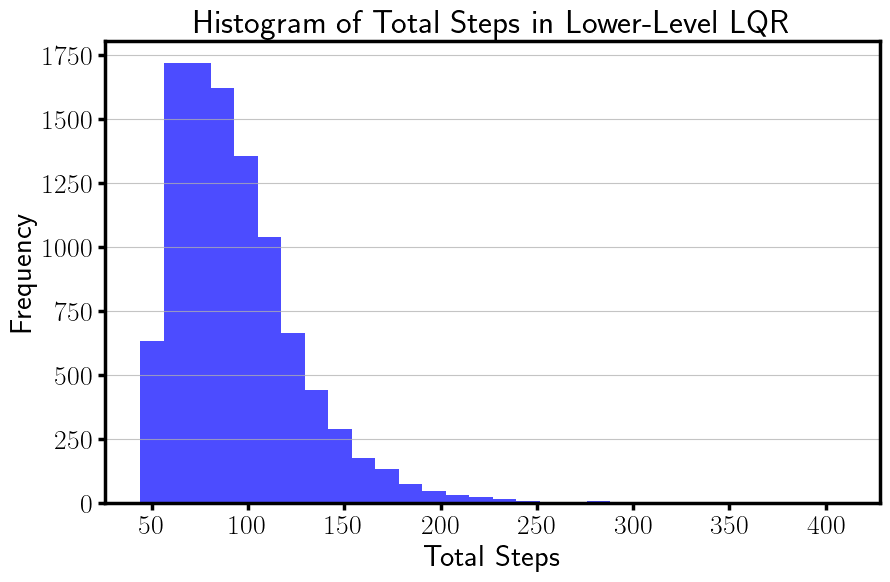

Scatter plot saved to /home/mikoto/workspace/BC-HG/configurable_mdp/notebooks/random_search_scatter_insulation_level_LQR_itr.pdf


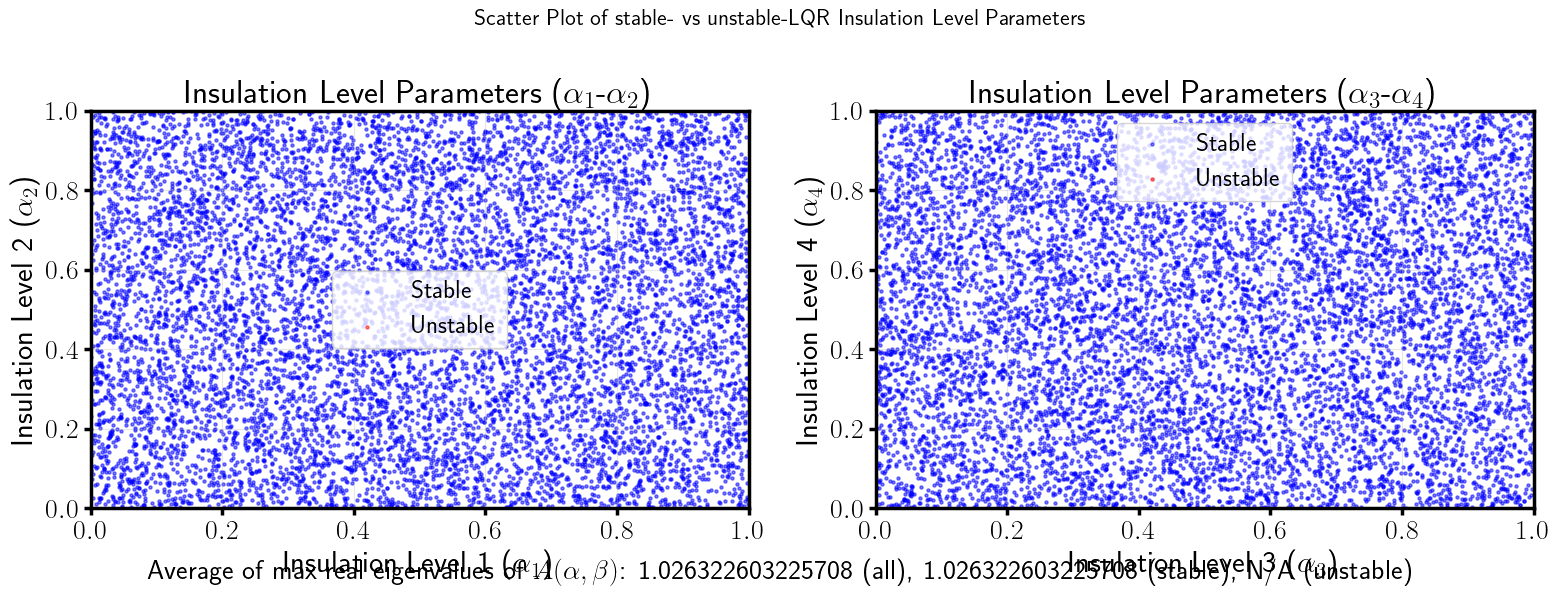

Scatter plot saved to /home/mikoto/workspace/BC-HG/configurable_mdp/notebooks/random_search_scatter_airflow_adjustment_LQR_itr.pdf


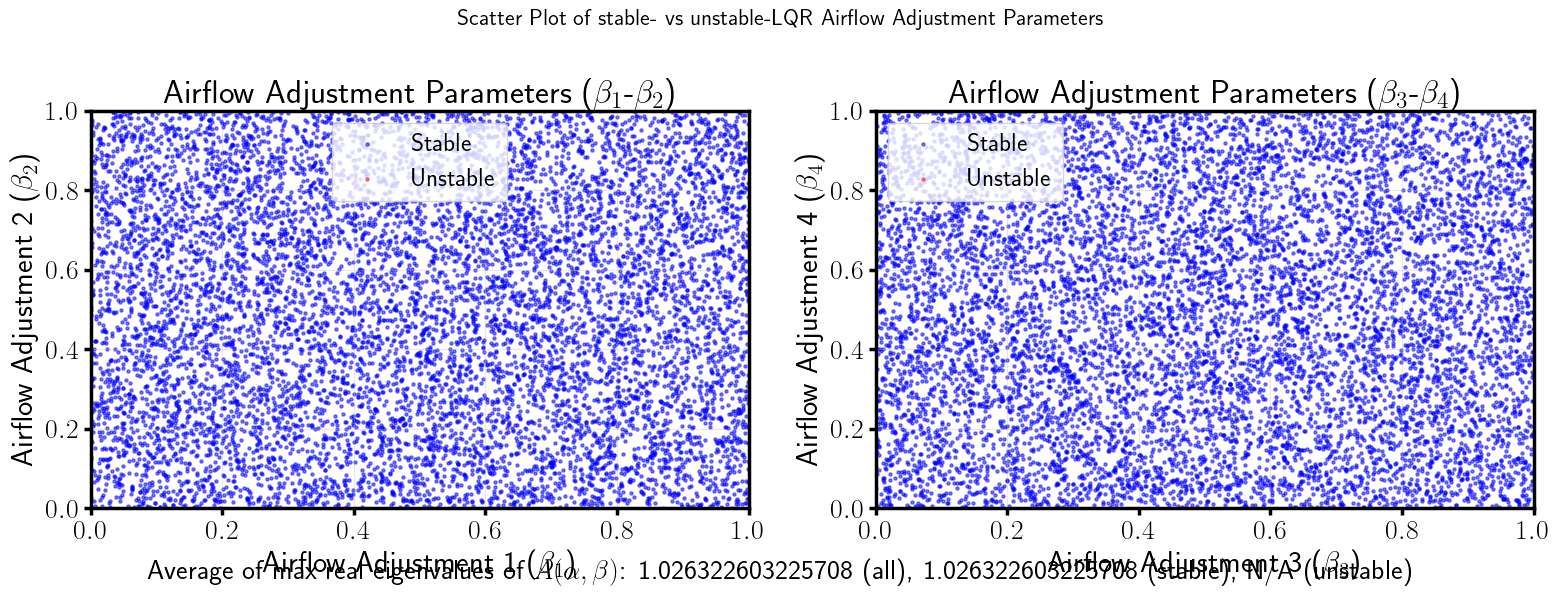

Average of max real eigenvalues (all): 1.026322603225708
Maximum of max real eigenvalues (all): 1.056217074394226
Minimum of max real eigenvalues (all): 1.0033197402954102
Stable rate in all samples: 0.00%
Average of max real eigenvalues (stable): 1.026322603225708
Maximum of max real eigenvalues (stable): 1.056217074394226
Minimum of max real eigenvalues (stable): 1.0033197402954102
Stable rate in stable samples: 0.00%
No samples in unstable.


In [51]:
lqr_metrics = outputs['metrics']

plt.figure(figsize=(10, 6))
plt.hist(lqr_metrics['total_steps'], bins=30, alpha=0.7, color='blue')
plt.title('Histogram of Total Steps in Lower-Level LQR')
plt.xlabel('Total Steps')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
if save:
    fig_path = os.path.join(save_dir, "random_search_histogram_LQR_itr.pdf")
    os.makedirs(os.path.dirname(fig_path), exist_ok=True)
    plt.savefig(fig_path, bbox_inches="tight")
    print(f"Histogram saved to {fig_path}")
plt.show()

max_itr = config['lower_optimisation']['training']['max_steps']
stable_indices = jnp.where(lqr_metrics['total_steps'] < max_itr)[0]
unstable_indices = jnp.where(lqr_metrics['total_steps'] == max_itr)[0]

good_parameters = {
    "insulation_level": insulation_level[stable_indices],
    "airflow_adjustment": airflow_adjustment[stable_indices],
}
bad_parameters = {
    "insulation_level": insulation_level[unstable_indices],
    "airflow_adjustment": airflow_adjustment[unstable_indices],
}

def safe_mean_text(x):
    return f"{jnp.mean(x)}" if x.size > 0 else "N/A"

for metric_name in ["insulation_level", "airflow_adjustment"]:
    arr_best = good_parameters[metric_name]  # (num_top, n_dim)
    arr_worst = bad_parameters[metric_name]  # (num_top, n_dim)
    ylim = (0.0, 1.0)
    notation = {
        "insulation_level": [rf"$\alpha_{i+1}$" for i in range(4)],
        "airflow_adjustment": [rf"$\beta_{i+1}$" for i in range(4)]
    }

    # Create two subplots side by side
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    for (i, j, ax) in [(0, 1, ax1), (2, 3, ax2)]:  # leftside: (0, 1), rightside: (2, 3)
        x_best = arr_best[:,i]
        y_best = arr_best[:,j]
        x_worst = arr_worst[:,i]
        y_worst = arr_worst[:,j]
        ax.scatter(x_best, y_best, color='blue', alpha=0.5, label='Stable', s=5)
        ax.scatter(x_worst, y_worst, color='red', alpha=0.5, label='Unstable', s=5)
        ax.set_title(f'{metric_name.replace("_", " ").title()} Parameters' + f' ({notation[metric_name][i]}-{notation[metric_name][j]})')
        ax.set_xlabel(f'{metric_name.replace("_", " ").title()} {i+1}' + f' ({notation[metric_name][i]})')
        ax.set_ylabel(f'{metric_name.replace("_", " ").title()} {j+1}' + f' ({notation[metric_name][j]})')
        ax.set_xlim(ylim)
        ax.set_ylim(ylim)
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    # Overall title
    fig.suptitle(f'Scatter Plot of stable- vs unstable-LQR {metric_name.replace("_", " ").title()} Parameters', fontsize=16)
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.15)
    plt.figtext(
        0.5,
        0.02,
        rf"Average of max real eigenvalues of $A(\alpha,\beta)$: {jnp.mean(max_real_eigenvalue)} (all), "
        + f"{safe_mean_text(max_real_eigenvalue[stable_indices])} (stable), "
        + f"{safe_mean_text(max_real_eigenvalue[unstable_indices])} (unstable)",
        ha='center',
        va='bottom',
        style='italic'
    )
    if save:
        fig_path = os.path.join(save_dir, f"random_search_scatter_{metric_name}_LQR_itr.pdf")
        os.makedirs(os.path.dirname(fig_path), exist_ok=True)
        plt.savefig(fig_path, bbox_inches="tight")
        print(f"Scatter plot saved to {fig_path}")
    plt.show()

# Information about Eigenvalues
max_real_eigenvalue_stable = max_real_eigenvalue[stable_indices]
max_real_eigenvalue_unstable = max_real_eigenvalue[unstable_indices]
is_stable_stable = is_stable[stable_indices]
is_stable_unstable = is_stable[unstable_indices]

def print_eigen_stats(label, eigenvalues, stable_flags):
    if eigenvalues.size == 0:
        print(f"No samples in {label}.")
        return
    print(f"Average of max real eigenvalues ({label}): {jnp.mean(eigenvalues)}")
    print(f"Maximum of max real eigenvalues ({label}): {jnp.max(eigenvalues)}")
    print(f"Minimum of max real eigenvalues ({label}): {jnp.min(eigenvalues)}")
    print(f"Stable rate in {label} samples: {jnp.mean(stable_flags) * 100:.2f}%")

print(f"Average of max real eigenvalues (all): {jnp.mean(max_real_eigenvalue)}")
print(f"Maximum of max real eigenvalues (all): {jnp.max(max_real_eigenvalue)}")
print(f"Minimum of max real eigenvalues (all): {jnp.min(max_real_eigenvalue)}")
print(f"Stable rate in all samples: {jnp.mean(is_stable) * 100:.2f}%")

print_eigen_stats("stable", max_real_eigenvalue_stable, is_stable_stable)
print_eigen_stats("unstable", max_real_eigenvalue_unstable, is_stable_unstable)

## Upper-level Objective

Histogram saved to /home/mikoto/workspace/BC-HG/configurable_mdp/notebooks/random_search_histogram_SR_1_0_EC_0_5_IC_0_1_AC_0_1.pdf


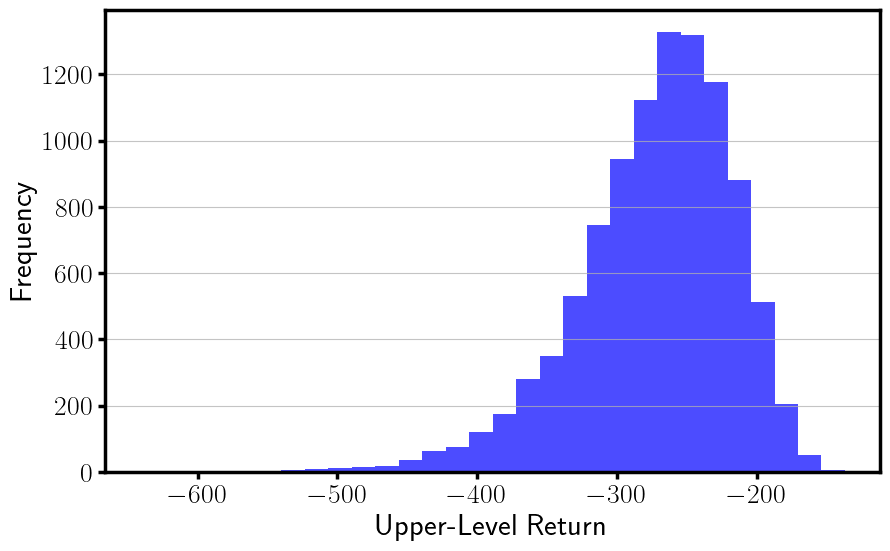

Average Upper-Level Return of Best 25 (Stable) Parameters: -156.5806
Average Upper-Level Return of Worst 25 (Stable) Parameters: -554.8403
Average Upper-Level Return of Stable (10000) Samples: -273.14514
Average Upper-Level Return of All (10000) Samples: -273.14514
(Transition batch size: 5000)

Details:


,Upper-level Return,Stability Reward (× 1.0),Energy Cost (× -0.5),Insulation Cost (× -0.1),Airflow Cost (× -0.1),Lower-level Return
Best,-156.5806,-81.33896,143.27446,18.552519,17.491478,-1542.9924
Worst,-554.8403,-370.611,365.7224,9.23441,4.446483,-4917.1636
Stable,-273.14514,-138.67,263.63324,13.297025,13.287978,-2250.8416
All,-273.14514,-138.67,263.63324,13.297025,13.287978,-2250.8416


In [52]:
# Make a histogram of Upper-Level Returns (Note: return_UL.shape = (num_samples,))

plt.figure(figsize=(10, 6))
plt.hist(return_UL, bins=30, alpha=0.7, color='blue')

plt.xlabel('Upper-Level Return')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
if save:
    fig_path = os.path.join(save_dir, f"random_search_histogram{reward_params_label}.pdf")
    os.makedirs(os.path.dirname(fig_path), exist_ok=True)
    plt.savefig(fig_path, bbox_inches="tight")
    print(f"Histogram saved to {fig_path}")
plt.show()

# Sort return_UL and get the best parameter sets
num_top = 25
sorted_indices = stable_indices[
    jnp.argsort(return_UL[stable_indices])
]  # Indices that would sort the stable returns

best_indices = sorted_indices[-num_top:]
worst_indices = sorted_indices[:num_top]

print(f"Average Upper-Level Return of Best {num_top} (Stable) Parameters:", jnp.mean(return_UL[best_indices]))
print(f"Average Upper-Level Return of Worst {num_top} (Stable) Parameters:", jnp.mean(return_UL[worst_indices]))
print(f"Average Upper-Level Return of Stable ({len(stable_indices)}) Samples:", jnp.mean(return_UL[stable_indices]))
print(f"Average Upper-Level Return of All ({len(return_UL)}) Samples:", jnp.mean(return_UL))
print(f"(Transition batch size: {config['upper_optimisation']['num_eval_steps']})")

print("\n" + "Details:")
import pandas as pd
return_table = pd.DataFrame({
    f"Upper-level Return": {
        "Best": jnp.mean(return_UL[best_indices]),
        "Worst": jnp.mean(return_UL[worst_indices]),
        "Stable": jnp.mean(return_UL[stable_indices]),
        "All": jnp.mean(return_UL),
        },
    f"  Stability Reward (× {env_params.reward_params.stability_weight})": {
        "Best": jnp.mean(return_UL_stability[best_indices]),
        "Worst": jnp.mean(return_UL_stability[worst_indices]),
        "Stable": jnp.mean(return_UL_stability[stable_indices]),
        "All": jnp.mean(return_UL_stability),
    },
    f"  Energy Cost (× {-env_params.reward_params.energy_weight})": {
        "Best": jnp.mean(return_UL_energy_cost[best_indices]),
        "Worst": jnp.mean(return_UL_energy_cost[worst_indices]),
        "Stable": jnp.mean(return_UL_energy_cost[stable_indices]),
        "All": jnp.mean(return_UL_energy_cost),
    },
    f"  Insulation Cost (× {-env_params.reward_params.insulation_cost_weight})": {
        "Best": jnp.mean(return_UL_insulation_cost[best_indices]),
        "Worst": jnp.mean(return_UL_insulation_cost[worst_indices]),
        "Stable": jnp.mean(return_UL_insulation_cost[stable_indices]),
        "All": jnp.mean(return_UL_insulation_cost),
    },
    f"  Airflow Cost (× {-env_params.reward_params.airflow_cost_weight})": {
        "Best": jnp.mean(return_UL_airflow_cost[best_indices]),
        "Worst": jnp.mean(return_UL_airflow_cost[worst_indices]),
        "Stable": jnp.mean(return_UL_airflow_cost[stable_indices]),
        "All": jnp.mean(return_UL_airflow_cost),
    },
    "Lower-level Return": {
        "Best": jnp.mean(return_LL[best_indices]),
        "Worst": jnp.mean(return_LL[worst_indices]),
        "Stable": jnp.mean(return_LL[stable_indices]),
        "All": jnp.mean(return_LL),
    },
})
display(return_table)

In [53]:
best_parameters = {
    "insulation_level": insulation_level[best_indices],
    "airflow_adjustment": airflow_adjustment[best_indices],
} 
worst_parameters = {
    "insulation_level": insulation_level[worst_indices],
    "airflow_adjustment": airflow_adjustment[worst_indices],
}
unstable_parameters = {
    "insulation_level": insulation_level[unstable_indices],
    "airflow_adjustment": airflow_adjustment[unstable_indices],
}

3D multi-view scatter plot saved to /home/mikoto/workspace/BC-HG/configurable_mdp/notebooks/random_search_3d_multi_view_insulation_level_SR_1_0_EC_0_5_IC_0_1_AC_0_1.pdf


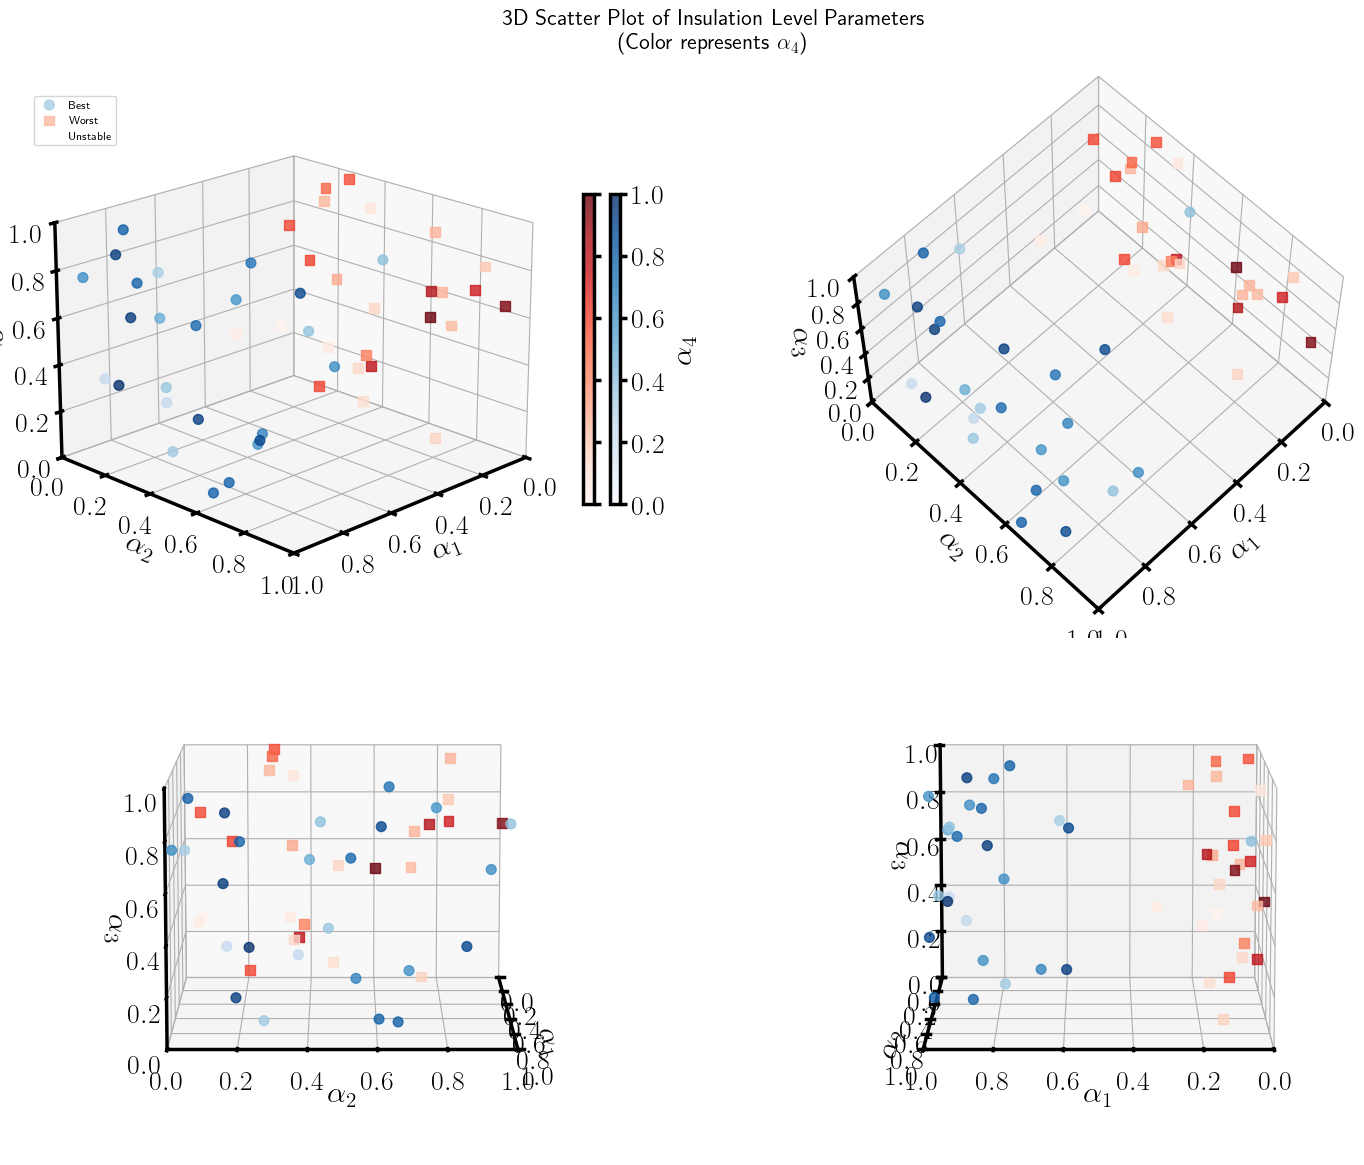

3D multi-view scatter plot saved to /home/mikoto/workspace/BC-HG/configurable_mdp/notebooks/random_search_3d_multi_view_airflow_adjustment_SR_1_0_EC_0_5_IC_0_1_AC_0_1.pdf


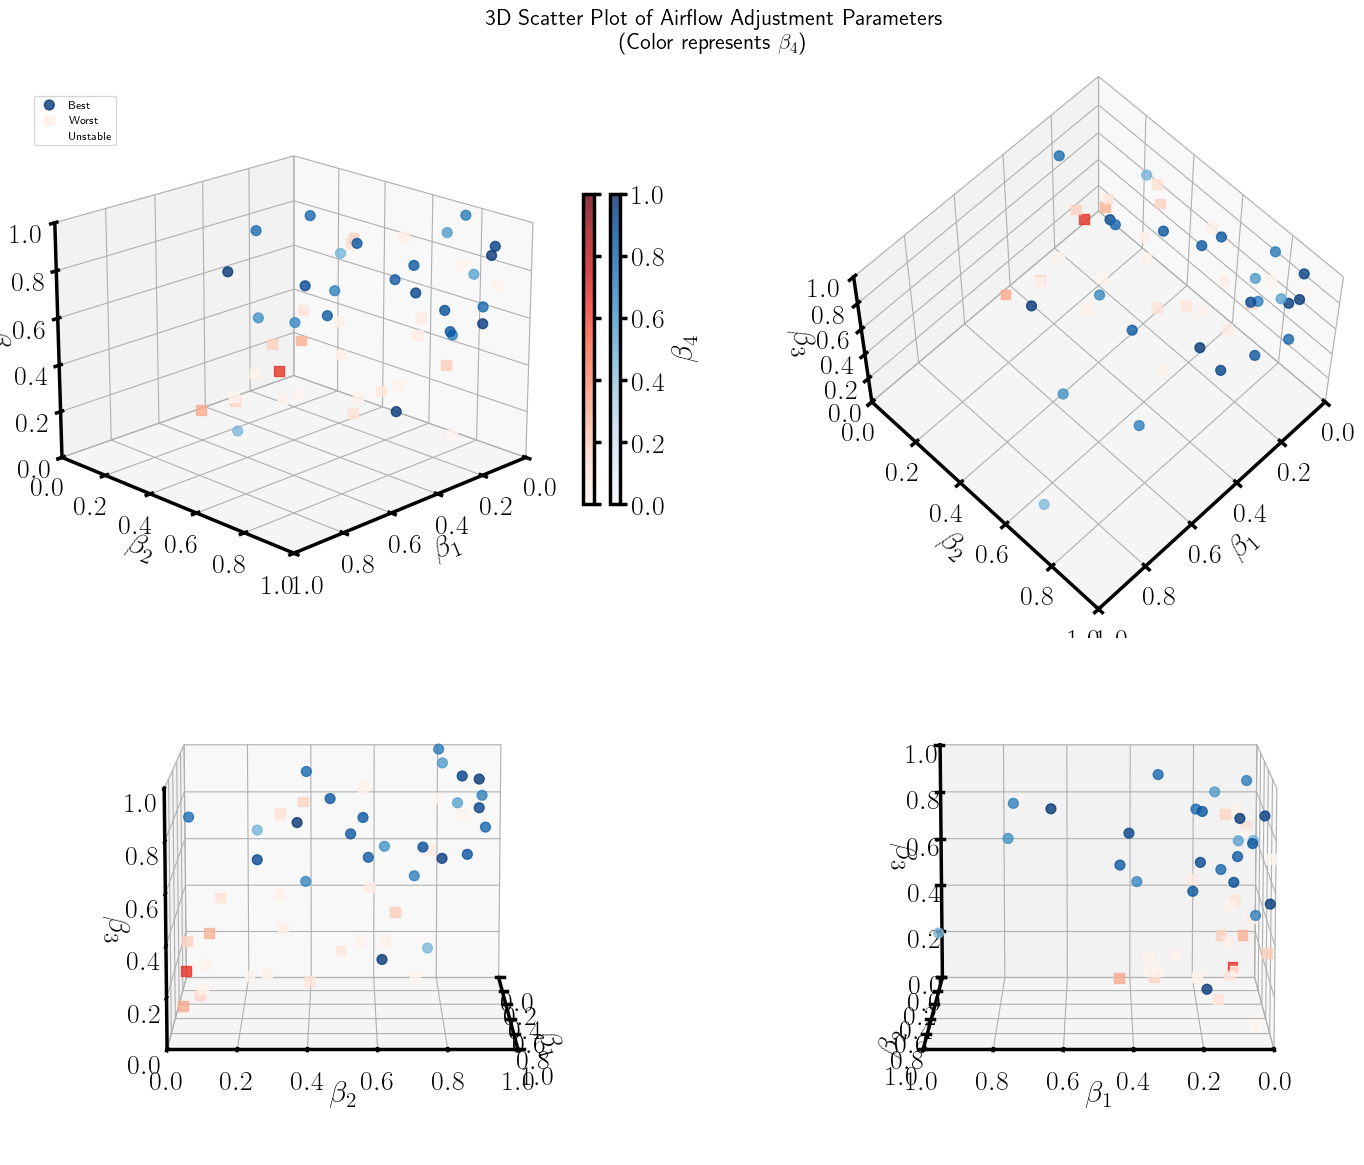

In [54]:
# 3D visualization
for metric_name in ["insulation_level", "airflow_adjustment"]:
    arr_best = best_parameters[metric_name]  # (num_top, n_dim)
    arr_worst = worst_parameters[metric_name]  # (num_top, n_dim)
    arr_unstable = unstable_parameters[metric_name]  # (num_unstable, n_dim)
    ylim = (0.0, 1.0)
    notation = {
        "insulation_level": [rf"$\alpha_{i+1}$" for i in range(4)],
        "airflow_adjustment": [rf"$\beta_{i+1}$" for i in range(4)]
    }

    # 2x2 subplots (3D scatter plots from different viewpoints)
    fig = plt.figure(figsize=(16, 12))
    
    # List of different viewpoints
    views = [
        (20, 45),   # Standard view
        (60, 45),  # Top view
        (10, 0),   # Side view
        (10, 90),   # Side view
    ]
    
    for idx, (elev, azim) in enumerate(views):
        ax = fig.add_subplot(2, 2, idx+1, projection='3d')
        
        # Convert data into 3D coordinates + color information
        x_best, y_best, z_best, color_best = arr_best[:,0], arr_best[:,1], arr_best[:,2], arr_best[:,3]
        x_worst, y_worst, z_worst, color_worst = arr_worst[:,0], arr_worst[:,1], arr_worst[:,2], arr_worst[:,3]
        x_unstable, y_unstable, z_unstable, color_unstable = arr_unstable[:,0], arr_unstable[:,1], arr_unstable[:,2], arr_unstable[:,3]
        
        # Plot 3D scatter
        scatter_best = ax.scatter(x_best, y_best, z_best, c=color_best, 
                                 cmap='Blues', marker='o', s=50, alpha=0.8, 
                                 label='Best', vmin=ylim[0], vmax=ylim[1])
        scatter_worst = ax.scatter(x_worst, y_worst, z_worst, c=color_worst, 
                                  cmap='Reds', marker='s', s=50, alpha=0.8, 
                                  label='Worst', vmin=ylim[0], vmax=ylim[1])
        scatter_unstable = ax.scatter(x_unstable, y_unstable, z_unstable, c=color_unstable, 
                                     cmap='Oranges', marker='x', s=30, alpha=0.6, 
                                     label='Unstable', vmin=ylim[0], vmax=ylim[1])
        
        # Set axis labels
        ax.set_xlabel(f'{notation[metric_name][0]}')
        ax.set_ylabel(f'{notation[metric_name][1]}')
        ax.set_zlabel(f'{notation[metric_name][2]}')
        
        # Set axis ranges
        ax.set_xlim(ylim)
        ax.set_ylim(ylim)
        ax.set_zlim(ylim)
        
        # Set viewpoint
        ax.view_init(elev=elev, azim=azim)
        
        # Add grid
        ax.grid(True, alpha=0.3)
        
        # Add legend only to the first subplot
        if idx == 0:
            ax.legend(loc='upper left', fontsize=8)
            # Add colorbar on the right side
            cbar1 = fig.colorbar(scatter_best, ax=ax, shrink=0.6, aspect=30, pad=-0.11)
            cbar2 = fig.colorbar(scatter_worst, ax=ax, shrink=0.6, aspect=30)
            cbar1.set_label(f'{notation[metric_name][3]}')
            cbar2.set_ticklabels([])
    
    # Overall title
    fig.suptitle(f'3D Scatter Plot of {metric_name.replace("_", " ").title()} Parameters\n'
                f'(Color represents {notation[metric_name][3]})', fontsize=16)
    
    plt.tight_layout()
    
    if save:
        fig_path = os.path.join(save_dir, f"random_search_3d_multi_view_{metric_name}{reward_params_label}.pdf")
        os.makedirs(os.path.dirname(fig_path), exist_ok=True)
        plt.savefig(fig_path, bbox_inches="tight", dpi=300)
        print(f"3D multi-view scatter plot saved to {fig_path}")
    
    plt.show()

In [55]:
# Interactive widgets
import ipywidgets as widgets
from IPython.display import display

def create_simple_side_by_side():
    @widgets.interact(
        elevation=widgets.IntSlider(min=0, max=90, step=5, value=20),
        azimuth=widgets.IntSlider(min=0, max=360, step=15, value=45),
        show_best=widgets.Checkbox(value=True, description='Show Best'),
        show_worst=widgets.Checkbox(value=True, description='Show Worst'),
        show_unstable=widgets.Checkbox(value=True, description='Show Unstable')
    )
    def plot_both_3d(elevation, azimuth, show_best, show_worst, show_unstable):
        # Create two subplots in one large figure
        fig = plt.figure(figsize=(16, 7))
        
        metric_names = ["insulation_level", "airflow_adjustment"]
        titles = ["Insulation Level Parameters", "Airflow Adjustment Parameters"]
        
        for i, (metric_name, title) in enumerate(zip(metric_names, titles)):
            ax = fig.add_subplot(1, 2, i+1, projection='3d')
            
            arr_best = best_parameters[metric_name]
            arr_worst = worst_parameters[metric_name] 
            arr_unstable = unstable_parameters[metric_name]
            ylim = (0.0, 1.0)
            notation = {
                "insulation_level": [rf"$\alpha_{i+1}$" for i in range(4)],
                "airflow_adjustment": [rf"$\beta_{i+1}$" for i in range(4)]
            }
            
            if show_best:
                scatter1 = ax.scatter(arr_best[:,0], arr_best[:,1], arr_best[:,2], 
                          c=arr_best[:,3], cmap='Blues', marker='o', 
                          s=60, alpha=0.8, label='Best', 
                          vmin=ylim[0], vmax=ylim[1])
            
            if show_worst:
                scatter2 = ax.scatter(arr_worst[:,0], arr_worst[:,1], arr_worst[:,2],
                          c=arr_worst[:,3], cmap='Reds', marker='s',
                          s=60, alpha=0.8, label='Worst',
                          vmin=ylim[0], vmax=ylim[1])
            
            if show_unstable:
                ax.scatter(arr_unstable[:,0], arr_unstable[:,1], arr_unstable[:,2],
                          c=arr_unstable[:,3], cmap='Oranges', marker='X',
                          s=40, alpha=0.6, label='Unstable',
                          vmin=ylim[0], vmax=ylim[1])
            
            ax.view_init(elev=elevation, azim=azimuth)
            ax.set_xlabel(f'{notation[metric_name][0]}', fontsize=11)
            ax.set_ylabel(f'{notation[metric_name][1]}', fontsize=11)
            ax.set_zlabel(f'{notation[metric_name][2]}', fontsize=11)
            ax.set_xlim(ylim)
            ax.set_ylim(ylim)
            ax.set_zlim(ylim)
            
            ax.set_title(f'{title}\nColor: {notation[metric_name][3]}', fontsize=12)
            ax.legend(fontsize=9)
            
            # Add colorbar
            if show_best and show_worst:
                cbar1 = plt.colorbar(scatter1, ax=ax, shrink=0.6, aspect=20, pad=-0.1)
                cbar2 = plt.colorbar(scatter2, ax=ax, shrink=0.6, aspect=20)
                cbar2.set_ticklabels([])
                cbar1.set_label(f'{notation[metric_name][3]}', fontsize=10)
            elif show_best:
                cbar = plt.colorbar(scatter1, ax=ax, shrink=0.6, aspect=20)
                cbar.set_label(f'{notation[metric_name][3]}', fontsize=10)
            elif show_worst:
                cbar = plt.colorbar(scatter2, ax=ax, shrink=0.6, aspect=20)
                cbar.set_label(f'{notation[metric_name][3]}', fontsize=10)
        
        plt.tight_layout()
        plt.show()

create_simple_side_by_side()

interactive(children=(IntSlider(value=20, description='elevation', max=90, step=5), IntSlider(value=45, descri…